In [22]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

#Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#Function plot
#xx = np.linspace(-1, 1, 400)
#plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
#plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
#plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
#plt.show()

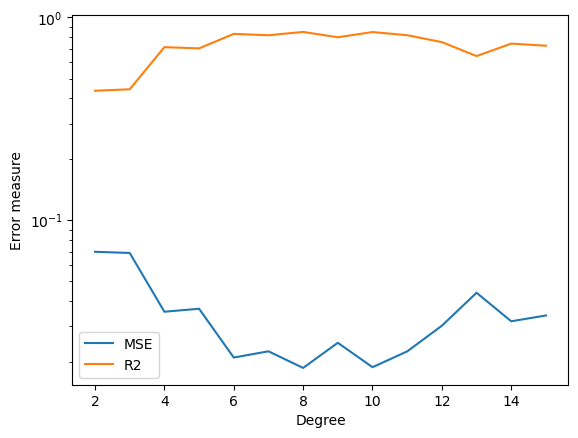

Optimal degree: 8


In [23]:
from sklearn.model_selection import train_test_split

def standardize(x_train, y_train, x_test, degree, intercept=True):
    '''Make and standardize design matrix for train and test data. Also return centered y training data and its mean'''
    start = 0 if intercept else 1
    X = np.vstack([x_train**p for p in range(start, degree + 1)]).T
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_std[X_std == 0] = 1
    X_norm = (X - X_mean) / X_std
    
    X_test = np.vstack([x_test**p for p in range(start, degree + 1)]).T
    X_test_norm = (X_test - X_mean) / X_std

    y_mean = y_train.mean()
    y_centered = y_train - y_mean
    return X_norm, y_centered, X_test_norm, y_mean

def ols(X, y):
    '''Return closed form OLS parameters'''
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def mse_r2_ols(x_train, x_test, y_train, y_test, deg):
    '''Return MSE and R2 score for a given train/test data set and degree'''
    X_train, y_train, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ols(X_train, y_train)
    y_pred = (X_test @ theta) + y_mean
    mse = np.mean((y_test - y_pred)**2)
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test-np.mean(y_test))**2)
    return mse, r2

degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate MSE and R2 for degrees 2-15                                                   
mses = []
r2s = []
for deg in range(2, degrees+1):
    mse, r2 = mse_r2_ols(x_train, x_test, y_train, y_test, deg)
    mses.append(mse)
    r2s.append(r2)

#Plot MSE and R2 for degrees 2-15
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(mses), label="MSE")
plt.plot(xx, np.array(r2s), label="R2")
plt.xlabel("Degree")
plt.ylabel("Error measure")
plt.yscale("log")
plt.legend()
plt.show()

#Print degree with lowest MSE
print(f"Optimal degree: {np.argmin(mses)+2}")

In [24]:
#Repeat WITHOUT standardizing to show that it gives the same result for OLS


def design(x, degree, intercept=True):
    '''Return design matrix for given x data and degree'''
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def non_standardized_error(x_train, x_test, y_train, y_test, deg):
    '''Return MSE and R2 score for a given train/test data set and degree without standardizing'''
    X_train = design(x_train, deg)
    X_test = design(x_test, deg)
    theta = ols(X_train, y_train)
    y_pred = (X_test @ theta)
    mse = np.mean((y_test - y_pred)**2)
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test-np.mean(y_test))**2)
    return mse, r2


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate MSE and R2 for degrees 2-15                                                   
mses_ns = []
r2s_ns = []
for deg in range(2, degrees+1):
    mse, r2 = non_standardized_error(x_train, x_test, y_train, y_test, deg)
    mses_ns.append(mse)
    r2s_ns.append(r2)

#Plot MSE and R2 for degrees 2-15 (non-standardized)
#xx = np.arange(2, degrees+1, 1)
#plt.plot(xx, np.array(mses_ns), label="MSE")
#plt.plot(xx, np.array(r2s_ns), label="R2")
#plt.xlabel("Degree")
#plt.ylabel("Error measure")
#plt.yscale("log")
#plt.legend()
#plt.show()

#Print degree with lowest MSE
#print(f"Optimal degree: {np.argmin(mses_ns)+2}")

#Print difference between MSE and R2 for standardized and non-standardized data set
print(f"Difference between standardized and non-standardized MSE: {np.abs(np.array(mses) - np.array(mses_ns))}")
print(f"Difference between standardized and non-standardized R2 score: {np.abs(np.array(r2s) - np.array(r2s_ns))}")

Difference between standardized and non-standardized MSE: [1.38777878e-17 0.00000000e+00 2.15105711e-16 2.01227923e-16
 2.14411822e-15 3.41393580e-15 1.28317496e-13 3.99999478e-13
 2.02009937e-12 9.48516266e-12 1.62664649e-10 1.18254460e-09
 2.81328195e-09 4.70263110e-09]
Difference between standardized and non-standardized R2 score: [1.11022302e-16 0.00000000e+00 1.77635684e-15 1.66533454e-15
 1.73194792e-14 2.76445533e-14 1.03606013e-12 3.22952776e-12
 1.63098424e-11 7.65809638e-11 1.31331557e-09 9.54758250e-09
 2.27137662e-08 3.79679199e-08]


Optimal degree 50 data points: 8
Optimal degree 100 data points: 5
Optimal degree 500 data points: 14
Optimal degree 1000 data points: 16


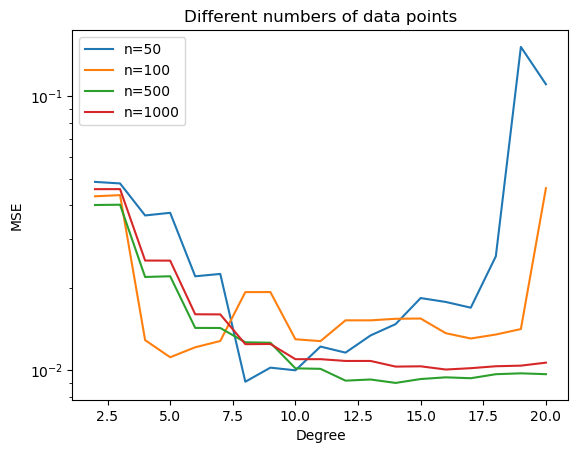

In [25]:
#Plot again for different number of data points
ns = np.array([50, 100, 500, 1000])
degrees = 20
rng = np.random.default_rng(0)

#Loop over different number of data points
for n in ns:
    sigma = 0.1                                  
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                        test_size=0.2, 
                                                        shuffle=True, 
                                                        random_state=2026)
    
    #Calculate MSE and R2 for degrees 2-15                                                   
    mses = []
    r2s = []
    for deg in range(2, degrees+1):
        mse, r2 = non_standardized_error(x_train, x_test, y_train, y_test, deg)
        mses.append(mse)
        r2s.append(r2)
    
    #Plot MSE and R2 for degrees 2-15
    xx = np.arange(2, degrees+1, 1)
    plt.plot(xx, np.array(mses), label=f"n={n}")
    #plt.plot(xx, np.array(r2s), label="R2")
    print(f"Optimal degree {n} data points: {np.argmin(mses)+2}")

#Fix plot
plt.title("Different numbers of data points")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.yscale("log")
plt.legend()
plt.show()   

In [26]:
# Kan sjekke for mange forskjellige rng og så ta gjennomsnitt

In [27]:
# FORSTÅ scaling (hvorfor blir det likt når jeg gjør standardised UTEN intercept og når jeg gjør non-standardized MED intercept? 
# Og hvor kommer egentlig bittelitt error fra?
#Teste for forskjellig noise

### Part b): Adding Ridge regression for the Runge function

Perform the same analysis as you did in the previous part but now for different
values of the penalty parameter $\lambda$. Compare and analyze your results with
those obtained in part a) with the OLS method. Study the dependence on
$\lambda$, and connect what you see to the shrinkage of the singular-value modes
discussed in the lectures (Section 3.8 of the lecture notes).

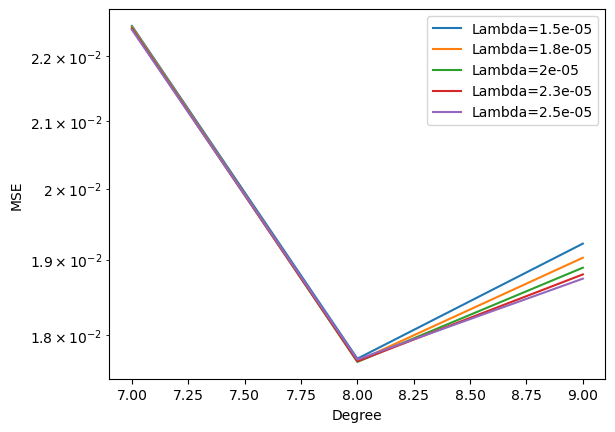

In [28]:
def ridge(X, y, lam=0.0):
    n, p = X.shape
    return np.linalg.pinv(X.T @ X + n * lam * np.eye(p)) @ X.T @ y
    
def mse_r2_ridge(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return MSE and R2 score for a given train/test data set and degree and lambda'''
    X_train, y_train, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train, lam)
    y_pred = X_test @ theta + y_mean
    mse = np.mean((y_test - y_pred)**2)
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum(y_test - np.mean(y_test))**2
    return mse, r2

#Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#Variables and split
degrees = 15
lmbdas = np.linspace(1.5e-5, 2.5e-5, 5)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Loop over lambdas
for lam in lmbdas:  
    #Calculate MSEs
    mses = []
    for deg in range(7, 9+1):
        mse, r2 = mse_r2_ridge(x_train, x_test, y_train, y_test, deg, lam)
        mses.append(mse)

    #Plot for the given lambda
    xx = np.arange(7, 9+1, 1)
    plt.plot(xx, np.array(mses), label=f"Lambda={lam:.2g}")

#Fix plot and show all
plt.ylabel("MSE")
plt.yscale("log")
plt.xlabel("Degree")
plt.legend(loc="upper right")
plt.show()

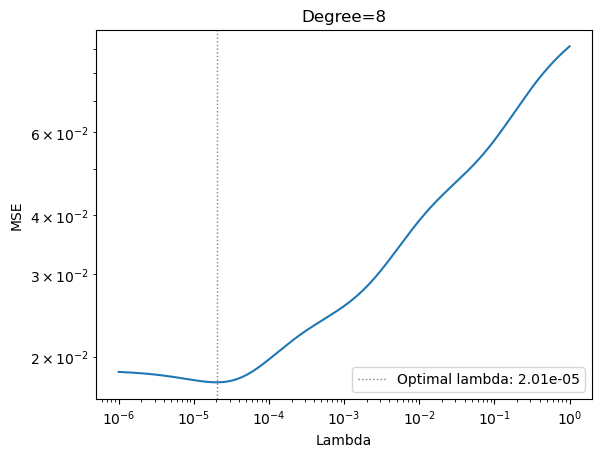

In [29]:
# Make plot for different lambdas at the optimal degree 8
degree = 8
lmbdas = np.logspace(-6, 0, 1000)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Loop over lambdas
mses = []
for lam in lmbdas:  
    #Calculate MSE
    mse, r2 = mse_r2_ridge(x_train, x_test, y_train, y_test, degree, lam)
    mses.append(mse)

best_l = lmbdas[np.argmin(mses)]
plt.xscale("log"); plt.xlabel("Lambda"); plt.ylabel("MSE"), plt.title(f"Degree={degree}") 
plt.axvline(best_l, color="gray", ls=":", lw=1, label=f"Optimal lambda: {best_l:.3g}")
plt.plot(lmbdas, np.array(mses))
plt.yscale("log")
plt.legend()
plt.show()

In [30]:
# forklar shrinkage of singular value modes

# GJØR A OG B MED MANGE FORSKJELLIGE SEEDS OG SJEKK HVILKEN DEGREE OG LAMBDA SOM ER BEST

### Part c): The bias-variance tradeoff and the bootstrap

Our aim here is to study the bias-variance tradeoff by implementing the
**bootstrap** resampling technique. **We will only use the simpler ordinary
least squares here.**

Before you perform an analysis of the bias-variance tradeoff on your test data,
make first a figure similar to Fig. 2.11 of Hastie, Tibshirani and Friedman.
Figure 2.11 of this reference displays only the test and training MSEs. The
test MSE can be used to indicate possible regions of low/high bias and variance.
You will most likely not get an equally smooth curve! You will also need to
increase the polynomial order and play around with the number of data points as
well (see the exercise sets from week 35 and week 36).

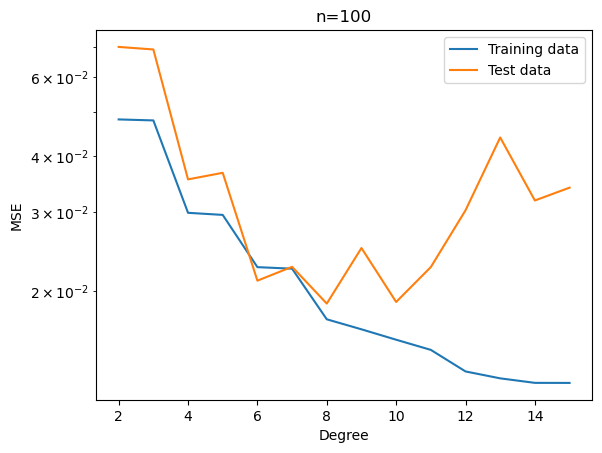

In [31]:
# Make figure 2.11 of Hastie et al.

def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

#Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate MSE and R2 for degrees 2-15                                                   
train_mses, test_mses = [], []
for deg in range(2, degrees+1):
    mse_train, mse_test = mses_tr_te(x_train, x_test, y_train, y_test, deg)
    train_mses.append(mse_train)
    test_mses.append(mse_test)

xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(train_mses), label="Training data")
plt.plot(xx, np.array(test_mses), label="Test data")
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.title(f"n={n}")
plt.legend()
plt.show()

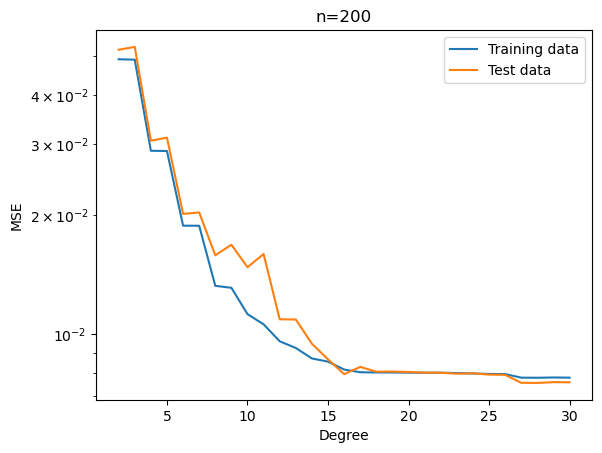

In [32]:
#Repeat for 200 data points

rng = np.random.default_rng(2026)
n = 200
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate MSE and R2 for degrees 2-15                                                   
train_mses, test_mses = [], []
for deg in range(2, degrees+1):
    mse_train, mse_test = mses_tr_te(x_train, x_test, y_train, y_test, deg)
    train_mses.append(mse_train)
    test_mses.append(mse_test)

xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(train_mses), label="Training data")
plt.plot(xx, np.array(test_mses), label="Test data")
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.title(f"n={n}")
plt.legend()
plt.show()

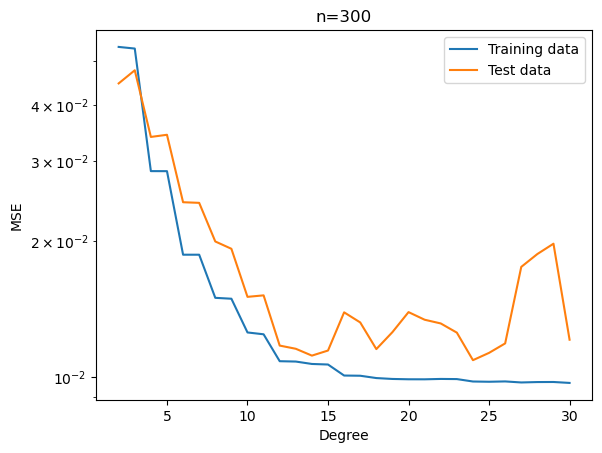

In [33]:
#Repeat for 300 data points

rng = np.random.default_rng(2026)
n = 300
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate MSE and R2 for degrees 2-15                                                   
train_mses, test_mses = [], []
for deg in range(2, degrees+1):
    mse_train, mse_test = mses_tr_te(x_train, x_test, y_train, y_test, deg)
    train_mses.append(mse_train)
    test_mses.append(mse_test)

xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(train_mses), label="Training data")
plt.plot(xx, np.array(test_mses), label="Test data")
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.title(f"n={n}")
plt.legend()
plt.show()

Perform then a bias-variance analysis of the Runge function by studying the MSE
value as function of the complexity of your model, using the **bootstrap**
resampling method to estimate the expectation values over training sets.
Discuss the bias and variance tradeoff as function of your model complexity (the
degree of the polynomial) and the number of data points. You can follow the
code examples in Sections 2.10 and 2.11 of the lecture notes and the Tuesday
notebook of week 36 (`week36tuesday.ipynb`).

In [34]:
#FEIL

"""

# Bootstraps for 100 data points
from sklearn.utils import resample

def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 100
degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

MSEs = []
for deg in range(2, degrees+1):
    mses = []
    for i in range(n_bootstraps):
        x_values, y_values = resample(x_train, y_train)
        mse = mses_tr_te(x_values, x_test, y_values, y_test, deg, lam = 0.0)
        mses.append(mse)
    MSE_for_degree = np.mean(np.array(mses))
    MSEs.append(MSE_for_degree)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs))
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title("100 data points, 100 bootstraps")
plt.show()

"""

'\n\n# Bootstraps for 100 data points\nfrom sklearn.utils import resample\n\ndef mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):\n    \'\'\'Return train MSE and test MSE for a given train/test data set and degree and lambda\'\'\'\n    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)\n    theta = ridge(X_train, y_train_centered, lam)\n    y_pred_train = X_train @ theta + y_mean\n    y_pred_test = X_test @ theta + y_mean\n    mse_train = np.mean((y_train - y_pred_train)**2)\n    mse_test = np.mean((y_test - y_pred_test)**2) \n    return mse_train, mse_test\n\n# Make data\nrng = np.random.default_rng(2026)\nn = 100\nsigma = 0.1                                  \nx = np.sort(rng.uniform(-1, 1, n))\ny = runge(x) + rng.normal(0, sigma, n)\n\n# Variables and split\nn_bootstraps = 100\ndegrees = 15\nx_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)\n\nMSEs = []\nfor deg 

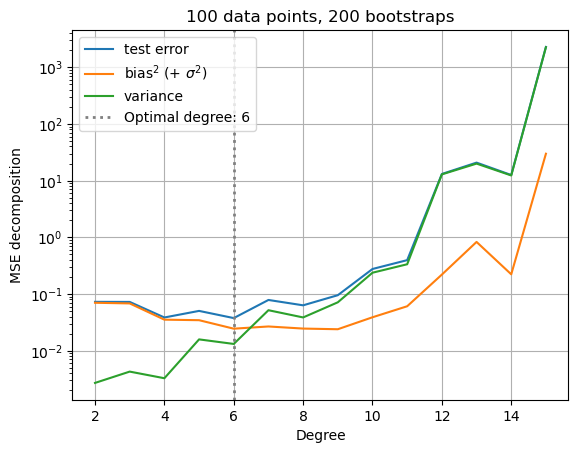

In [35]:
from sklearn.utils import resample
def bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg, lam = 0.0): 
    '''Resamples training data n_bootstrap times and returns MSE, bias and variance for the given degree'''
    preds = np.zeros((len(y_test), n_bootstraps))
    mses = []
    for i in range(n_bootstraps):
        x_values, y_values = resample(x_train, y_train)
        X_train, y_train_centered, X_test, y_mean = standardize(x_values, y_values, x_test, deg, intercept=False)
        theta = ridge(X_train, y_train_centered, lam=0.0)
        y_pred = X_test @ theta + y_mean
        preds[:, i] = y_pred
    
    #All predictions are stored. Calculate MSE, bias, variance
    mse_per_test_point = np.mean((y_test.reshape(-1, 1) - preds)**2, axis=1)
    MSE = np.mean(mse_per_test_point)
    mean_per_pred_point = np.mean(preds, axis=1)
    bias = np.mean((y_test - mean_per_pred_point)**2)
    var_per_pred_point = np.var(preds, axis=1)
    variance = np.mean(var_per_pred_point)
    
    return MSE, bias, variance

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 200
degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate stats for different degrees
MSEs = []
biases = []
variances = []
for deg in range(2, degrees+1):
    MSE, bias, variance = bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg)
    MSEs.append(MSE)
    biases.append(bias)
    variances.append(variance)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs), label="test error"); plt.plot(xx, np.array(biases), label=r"bias$^2$ (+ $\sigma^2$)")
plt.plot(xx, np.array(variances), label="variance")
plt.yscale("log"); plt.ylabel("MSE decomposition"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title(f"{n} data points, {n_bootstraps} bootstraps")
plt.show()

In [36]:
# når jeg kjører koden på nytt så får jeg nye plots siden resample ikke har seed. 
# Jeg kan kjøre hele koden mange ganger og ta average over alle resultatene?

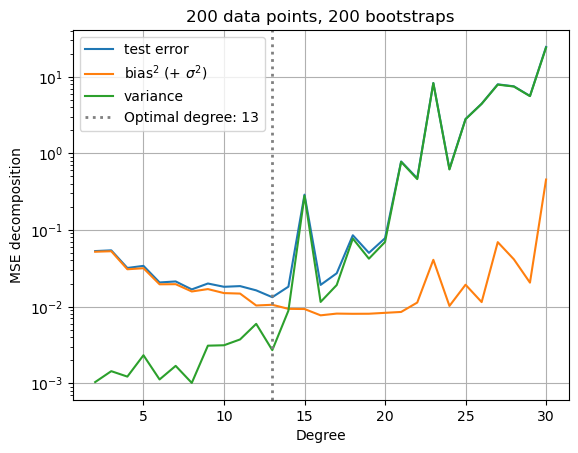

In [37]:
#Repeat for 200 data points

# Make data
rng = np.random.default_rng(2026)
n = 200
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 200
degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate stats for different degrees
MSEs = []
biases = []
variances = []
for deg in range(2, degrees+1):
    MSE, bias, variance = bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg)
    MSEs.append(MSE)
    biases.append(bias)
    variances.append(variance)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs), label="test error"); plt.plot(xx, np.array(biases), label=r"bias$^2$ (+ $\sigma^2$)")
plt.plot(xx, np.array(variances), label="variance")
plt.yscale("log"); plt.ylabel("MSE decomposition"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title(f"{n} data points, {n_bootstraps} bootstraps")
plt.show()

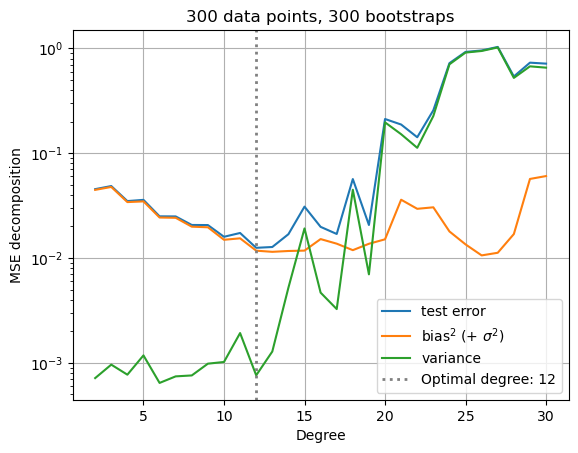

In [38]:
#Repeat for 300 data points

# Make data
rng = np.random.default_rng(2026)
n = 300
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 300
degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate stats for different degrees
MSEs = []
biases = []
variances = []
for deg in range(2, degrees+1):
    MSE, bias, variance = bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg)
    MSEs.append(MSE)
    biases.append(bias)
    variances.append(variance)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs), label="test error"); plt.plot(xx, np.array(biases), label=r"bias$^2$ (+ $\sigma^2$)")
plt.plot(xx, np.array(variances), label="variance")
plt.yscale("log"); plt.ylabel("MSE decomposition"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title(f"{n} data points, {n_bootstraps} bootstraps")
plt.show()

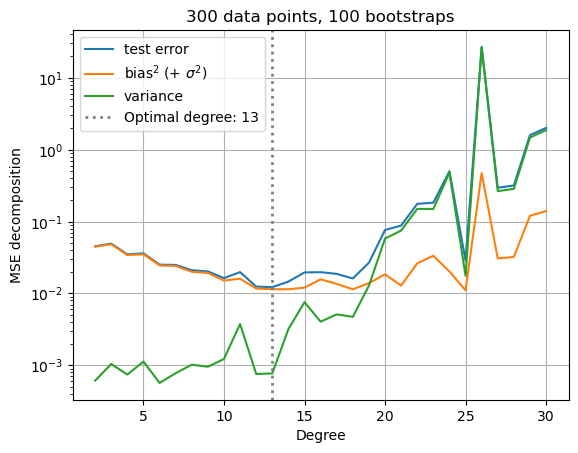

In [39]:
#Repeat for 300 data points

# Make data
rng = np.random.default_rng(2026)
n = 300
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 100
degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate stats for different degrees
MSEs = []
biases = []
variances = []
for deg in range(2, degrees+1):
    MSE, bias, variance = bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg)
    MSEs.append(MSE)
    biases.append(bias)
    variances.append(variance)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs), label="test error"); plt.plot(xx, np.array(biases), label=r"bias$^2$ (+ $\sigma^2$)")
plt.plot(xx, np.array(variances), label="variance")
plt.yscale("log"); plt.ylabel("MSE decomposition"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title(f"{n} data points, {n_bootstraps} bootstraps")
plt.show()

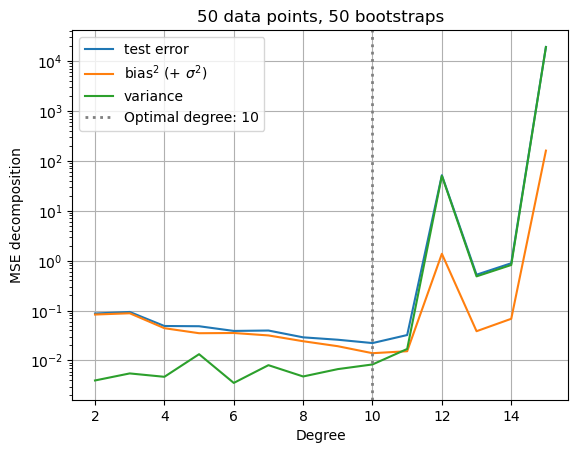

In [40]:
#Repeat for 50 data points

# Make data
rng = np.random.default_rng(2026)
n = 50
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 50
degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

#Calculate stats for different degrees
MSEs = []
biases = []
variances = []
for deg in range(2, degrees+1):
    MSE, bias, variance = bootstrap_stats(n_bootstraps, x_train, x_test, y_train, y_test, deg)
    MSEs.append(MSE)
    biases.append(bias)
    variances.append(variance)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs), label="test error"); plt.plot(xx, np.array(biases), label=r"bias$^2$ (+ $\sigma^2$)")
plt.plot(xx, np.array(variances), label="variance")
plt.yscale("log"); plt.ylabel("MSE decomposition"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.legend()
plt.title(f"{n} data points, {n_bootstraps} bootstraps")
plt.show()

The bias of a model describes how well the model describes the true non-stochastic function behind the data points. High bias means a bad fit of the true function. The bias usually decreases with model complexity since higher complexity (higher degree in our case) more precisely describes the function, as more parameters can be tuned. When more parameters can be tuned, each parameter gets more sensitive to the set of training data points, as changing many parameters can give a function that describes the trainig points more precisely. This sensitivity to training data usually leads to a higher variance between different training data sets, meaning the model gets less "stable". To minimize the test error, there is therefore a trade-off between increasing model complexity to precisely describe data points, and, on the other hand, keep the complexity low enough to get stable parameters from one set of training data to another. 

Increasing the number of data points usually means a higher model complexity can remain stable, since the parameters are based off more data and therefore gets closer to the true function. This means that generally, more data points will have a higher optimal model complexity.

The plots above show that the test error is dominated by the bias for low complexity degree. With increasing complexity the variance increases and blows up at certain degrees, starting to dominate. This is what we predict from the description above. The relation with number of data points is hard to analyse based on the plots above. 

!! SHOULD run many times for each number of data points to find average and understand the relation with number of bootstraps  

In [41]:
#PRØV TING HER

from sklearn.utils import resample

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
n_bootstraps = 100
degrees = 30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)

preds = np.zeros((len(y_test), 100))
print(np.shape(preds))

x_values, y_values = resample(x_train, y_train)
X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
theta = ridge(X_train, y_train_centered, lam=0.0)
y_pred = X_test @ theta + y_mean
y_preds = y_pred.ravel()
preds[:, 0] = y_pred
print(np.shape(y_test))
print(np.shape(y_test.reshape(-1, 1)))
#print(preds)
#error = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
print(np.shape(np.mean(preds, axis=1)))
print(np.shape(preds))

def bootstraps(n_bootstraps, x_train, x_test, y_train, y_test, deg, lam = 0.0): 
    preds = np.zeros((len(y_test), n_bootstraps))
    mses = []
    for i in range(n_bootstraps):
        x_values, y_values = resample(x_train, y_train)
        X_train, y_train_centered, X_test, y_mean = standardize(x_values, y_values, x_test, deg, intercept=False)
        theta = ridge(X_train, y_train_centered, lam=0.0)
        y_pred = X_test @ theta + y_mean
        preds[:, i] = y_pred
    
    #All predictions are stored. Now calculate MSE
    mse_per_test_point = np.mean((y_test.reshape(-1, 1) - preds)**2, axis=1)
    #print(mse_per_test_point)
    MSE = np.mean(mse_per_test_point)
    return MSE

(20, 100)
(20,)
(20, 1)
(20,)
(20, 100)


### Part d): Cross-validation as a resampling technique

Use the $k$-fold cross-validation functionality of **Scikit-Learn** (`KFold`
together with `cross_val_score`, or `cross_validate`) and evaluate again the
MSE function resulting from the test folds, for the OLS analysis of parts a)
and c) as a function of the polynomial degree, and for Ridge regression as a
function of both the polynomial degree and $\lambda$. Try $k=5$ and $k=10$.
Optionally, you can also write your own $k$-fold cross-validation code and
check that it reproduces the Scikit-Learn results when the two use the same
fold assignment (the Tuesday session of week 36 shows how).

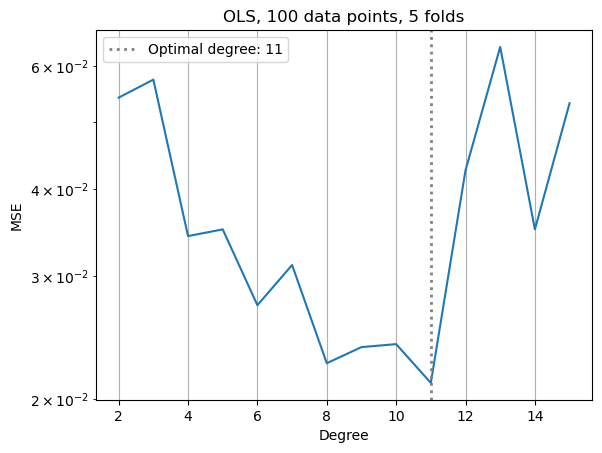

In [42]:
from sklearn.model_selection import KFold

def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

def CV(deg, k, x, y):
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    test_MSEs = np.zeros(k)
    for i, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        _, mse_test = mses_tr_te(xtrain, xtest, ytrain, ytest, deg)
        test_MSEs[i] = mse_test

    MSE_mean = np.mean(test_MSEs)
    MSE_std = np.std(test_MSEs, ddof=1)

    return MSE_mean, MSE_std

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
k = 5
degrees = 15

#Calculate MSE through k-fold cross-validation for different degrees
MSEs = []
for deg in range(2, degrees+1):
    MSE, _ = CV(deg, k, x, y)
    MSEs.append(MSE)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs))
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.title(f"OLS, {n} data points, {k} folds")
plt.legend()
plt.show()

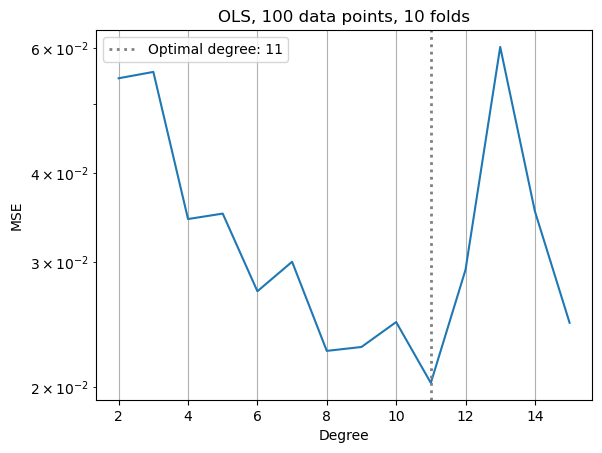

In [43]:
def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

def CV(deg, k, x, y):
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    test_MSEs = np.zeros(k)
    for i, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        _, mse_test = mses_tr_te(xtrain, xtest, ytrain, ytest, deg)
        test_MSEs[i] = mse_test

    MSE_mean = np.mean(test_MSEs)
    MSE_std = np.std(test_MSEs, ddof=1)

    return MSE_mean, MSE_std

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
k = 10
degrees = 15

#Calculate MSE through k-fold cross-validation for different degrees
MSEs = []
for deg in range(2, degrees+1):
    MSE, _ = CV(deg, k, x, y)
    MSEs.append(MSE)

best_degree = np.argmin(MSEs) + 2
xx = np.arange(2, degrees+1, 1)
plt.plot(xx, np.array(MSEs))
plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.grid(True)
plt.axvline(best_degree, color="gray", ls=":", lw=2, label=f"Optimal degree: {best_degree}")
plt.title(f"OLS, {n} data points, {k} folds")
plt.legend()
plt.show()

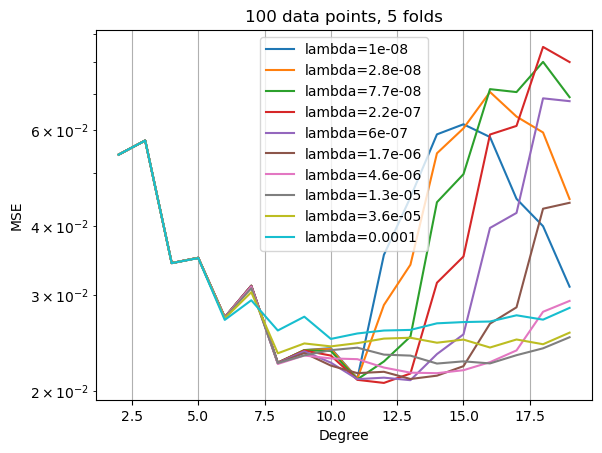

In [44]:
def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

def CV(deg, k, x, y, lam=0.0):
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    test_MSEs = np.zeros(k)
    for i, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        _, mse_test = mses_tr_te(xtrain, xtest, ytrain, ytest, deg, lam)
        test_MSEs[i] = mse_test

    MSE_mean = np.mean(test_MSEs)
    MSE_std = np.std(test_MSEs, ddof=1)

    return MSE_mean, MSE_std

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
k = 5
lmbdas = np.logspace(-8, -4, 10)
degrees = 19

#Calculate MSE through k-fold cross-validation for different degrees and lambdas
for lam in lmbdas:   
    MSEs = []
    for deg in range(2, degrees+1):
        MSE, _ = CV(deg, k, x, y, lam)
        MSEs.append(MSE)


    xx = np.arange(2, degrees+1, 1)
    plt.plot(xx, np.array(MSEs), label=f"lambda={lam:.2g}")

plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.grid(True)
plt.title(f"{n} data points, {k} folds")
plt.legend()
plt.show()

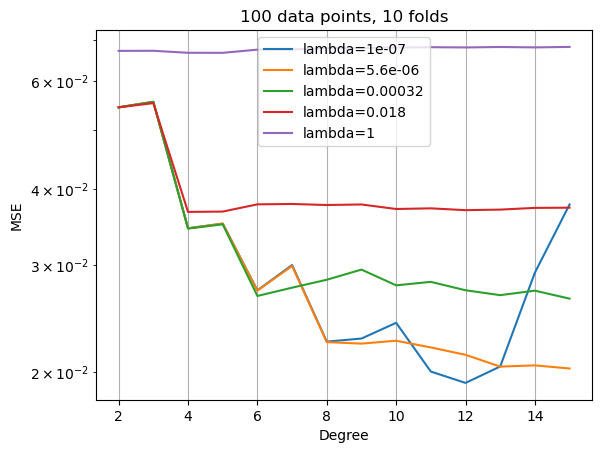

In [45]:
def mses_tr_te(x_train, x_test, y_train, y_test, deg, lam = 0.0):
    '''Return train MSE and test MSE for a given train/test data set and degree and lambda'''
    X_train, y_train_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    theta = ridge(X_train, y_train_centered, lam)
    y_pred_train = X_train @ theta + y_mean
    y_pred_test = X_test @ theta + y_mean
    mse_train = np.mean((y_train - y_pred_train)**2)
    mse_test = np.mean((y_test - y_pred_test)**2) 
    return mse_train, mse_test

def CV(deg, k, x, y, lam=0.0):
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    test_MSEs = np.zeros(k)
    for i, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        _, mse_test = mses_tr_te(xtrain, xtest, ytrain, ytest, deg, lam)
        test_MSEs[i] = mse_test

    MSE_mean = np.mean(test_MSEs)
    MSE_std = np.std(test_MSEs, ddof=1)

    return MSE_mean, MSE_std

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

# Variables and split
k = 10
lmbdas = np.logspace(-7, 0, 5)
degrees = 15

#Calculate MSE through k-fold cross-validation for different degrees and lambdas
for lam in lmbdas:   
    MSEs = []
    for deg in range(2, degrees+1):
        MSE, _ = CV(deg, k, x, y, lam)
        MSEs.append(MSE)


    xx = np.arange(2, degrees+1, 1)
    plt.plot(xx, np.array(MSEs), label=f"lambda={lam:.2g}")

plt.yscale("log"); plt.ylabel("MSE"); plt.xlabel("Degree"); plt.grid(True)
plt.title(f"{n} data points, {k} folds")
plt.legend()
plt.show()

Compare the MSE you get from cross-validation with the one you got
from your **bootstrap** code in part c). Do the two methods point to the same
model complexity? Comment and interpret your results. Make sure that any scaling
or other preprocessing that learns from the data is performed *inside* the
cross-validation loop (fitted on the training folds only), and explain why this
matters.

12.0
8.2


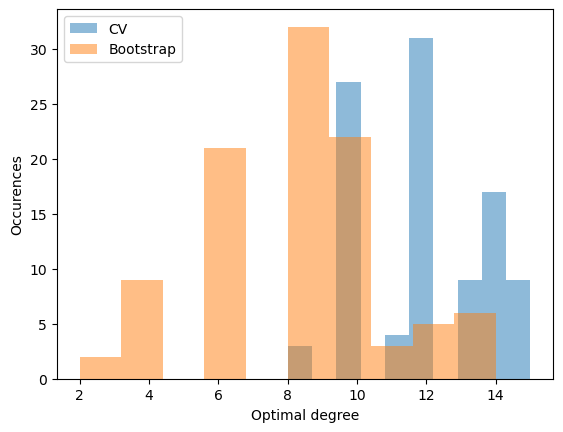

In [46]:
# Compare optimal degree from bootstrap and cross validation for 100 different seeds

selected_cv = []
selected_bootstrap = []

for seed in range(100):
    rng = np.random.default_rng(seed)

    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    # CV
    cv_mses = [
        CV(deg, k, x, y)[0]
        for deg in range(2, degrees + 1)
    ]
    selected_cv.append(np.argmin(cv_mses) + 2)

    # Bootstrap
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, shuffle=True, random_state=seed
    )

    bootstrap_mses = [
        bootstrap_stats(
            n_bootstraps,
            x_train, x_test,
            y_train, y_test,
            deg
        )[0]
        for deg in range(2, degrees + 1)
    ]
    selected_bootstrap.append(np.argmin(bootstrap_mses) + 2)


print(np.mean(selected_cv))
print(np.mean(selected_bootstrap))

plt.hist(selected_cv, alpha=0.5, label="CV")
plt.hist(selected_bootstrap, alpha=0.5, label="Bootstrap")
plt.xlabel("Optimal degree")
plt.ylabel("Occurences")
plt.legend()
plt.show()

In [47]:
# DISKUTER hva det gir mening å få som optimal degree av CV og bootstraps
# Gjør Ridge-testene med flere forskjellige lambdaer

### Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

In [49]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

'''
# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])
'''
def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)
'''
# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
'''

'\n# gradients by automatic differentiation (with respect to argument 0 = theta)\ngrad_ols_ad = jax.grad(cost_ols)\ngrad_ridge_ad = jax.grad(cost_ridge)\n\n# the same gradients by hand\ngrad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)\ngrad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0\n\nprint("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))\nprint("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))\n\n# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)\nH = 2.0 / len(y) * X.T @ X\nprint("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())\n'


Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

Gamma = 0.01: coefficients: [-0.04616871 -0.77807364  0.11578817  0.65966125  0.01365004  0.19533595
 -0.08445748 -0.29682525], not converged
Gamma = 0.1: coefficients: [-0.04300297 -1.13398424  0.16026643  1.65801233 -0.21840589 -0.52449699
  0.08387796 -0.23542232], not converged
Gamma=(0.5): coefficients: [-28433.93582845  36721.26763297 -35393.5247508   41311.56106794
 -38182.18801795  43657.16485071 -39823.16231476  44940.51504418], DIVERGED
Gamma=(0.8): coefficients: [-20672.23401292  31016.16322763 -26141.47954248  34569.68557493
 -28547.84095452  36242.97769553 -30045.37212076  37073.65763187], DIVERGED


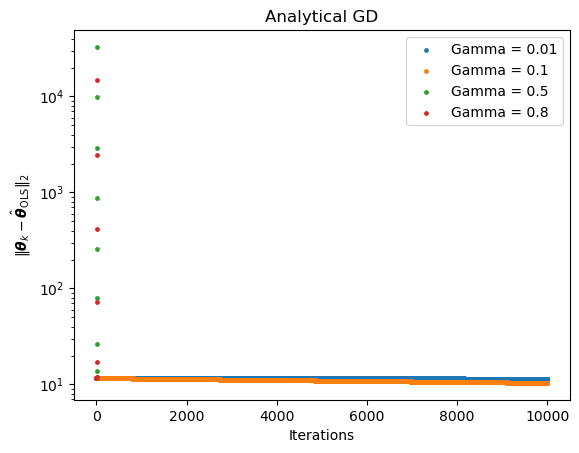

In [50]:
# Your gradient descent code for part e) here (use both gradients!)
# use gradient descent to find the optimal parameters theta for OLS and Ridge: start with theta = np.zeros(len(deg))
# og oppdater hver iteration

def analytic_grad_OLS(theta, X, y):
    return 2.0 / len(y) * X.T @ (X @ theta - y)

def analytic_grad_Ridge(theta, X, y, lmbda):
    return analytic_grad_OLS(theta, X, y) + 2.0 * lmbda * theta

# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#Use degree = 8
deg = 8

#Split and standardize
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)
X, y, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)

#Initiate simulation parameters
gamma = [0.01, 0.1, 0.5, 0.8]
#gamma = [0.229]
num_iters = 10000
tol = 1e-6
upper_lim = 1e5

# Analytical gradient descent
for i in range(len(gamma)):
    theta_gdOLS = np.zeros(deg)
    theta_cfOLS = ols(X, y)
    errors = []
    for t in range(num_iters):
        err_OLS = np.linalg.norm(theta_gdOLS - theta_cfOLS)
        errors.append(err_OLS)
        if err_OLS >= tol:
            grad_OLS = analytic_grad_OLS(theta_gdOLS, X, y)
            theta_gdOLS = theta_gdOLS - gamma[i]*grad_OLS
        else:
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, iterations: {t}")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
            break
        if t == (num_iters-1):
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, not converged")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
        if np.linalg.norm(grad_OLS) >= upper_lim:
                print(f"Gamma=({gamma[i]}): coefficients: {theta_gdOLS}, DIVERGED")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
                break

plt.legend()
plt.title("Analytical GD")
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

Gamma = 0.01: coefficients: [-0.04616871 -0.77807364  0.11578817  0.65966125  0.01365004  0.19533595
 -0.08445748 -0.29682525], not converged
Gamma = 0.1: coefficients: [-0.04300297 -1.13398424  0.16026643  1.65801233 -0.21840589 -0.52449699
  0.08387796 -0.23542232], not converged
Gamma=(0.5): coefficients: [-28433.93582845  36721.26763297 -35393.5247508   41311.56106794
 -38182.18801795  43657.16485071 -39823.16231476  44940.51504418], DIVERGED
Gamma=(0.8): coefficients: [-20672.23401292  31016.16322763 -26141.47954248  34569.68557493
 -28547.84095452  36242.97769553 -30045.37212076  37073.65763187], DIVERGED


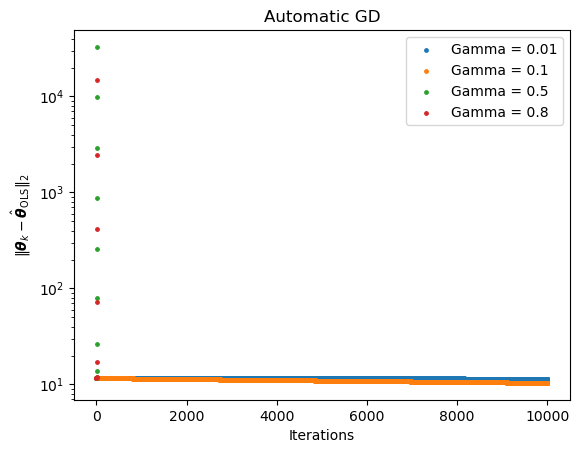

In [55]:
# Make data
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#Use degree = 8
deg = 8

#Split and standardize
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)
X, y, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)

#Initiate simulation parameters
gamma = [0.01, 0.1, 0.5, 0.8]
#gamma = [0.229]
num_iters = 10000
tol = 1e-6
upper_lim = 1e5

# Automatic gradient descent
for i in range(len(gamma)):
    theta_gdOLS = np.zeros(deg)
    theta_cfOLS = ols(X, y)
    errors = []
    for t in range(num_iters):
        err_OLS = np.linalg.norm(theta_gdOLS - theta_cfOLS)
        errors.append(err_OLS)
        if err_OLS >= tol:
            grad_OLS = jax.grad(cost_ols)(theta_gdOLS, X, y)
            theta_gdOLS = theta_gdOLS - gamma[i]*grad_OLS
        else:
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, iterations: {t}")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
            break
        if t == (num_iters-1):
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, not converged")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
        if np.linalg.norm(grad_OLS) >= upper_lim:
                print(f"Gamma=({gamma[i]}): coefficients: {theta_gdOLS}, DIVERGED")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
                break

plt.legend()
plt.title("Automatic GD")
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

We see that for the higher learning rates 0.5 and 0.8, theta quickly diverges. For 0.1 and 0.01, theta approaches the closed form solution but does not get closer than a norm error of 10 in 10000 iterations. To adjust the learning rate it is useful to take into account the analytical expression for the largest learning rate for which the gradient descent converges: below $2/\lambda_{eigmax}$ . The expression for the fastest convergence is given by $2/(\lambda_{eigmax}+\lambda_{eigmin})$

Both analytical and automatic differentiation gives these results. Automatic differentiation processing time was many seconds, compared with analytic which was less than a second. 

In [56]:
def eigenvalues(X_norm, y, lam):
    degree = np.shape(X_norm)[1]
    H_Ridge = (2/(len(y))) * (X_norm.T @ X_norm) + 2*lam*np.eye(degree)
    Ridge_eigenvalues = np.linalg.eigvalsh(H_Ridge)
    Ridge_eigmax = Ridge_eigenvalues[-1]
    Ridge_eigmin = Ridge_eigenvalues[0]
    
    return Ridge_eigmax, Ridge_eigmin

eigmax, eigmin = eigenvalues(X, y, 0)
largest_gamma = 2 / eigmax
fast_converge = 2 / (eigmax + eigmin)

print(f"largest gamma = {largest_gamma}")
print(f"fastest convergence = {fast_converge}")

largest gamma = 0.22980567198103052
fastest convergence = 0.22980274127796463


In [57]:
def make_data():
    rng = np.random.default_rng(2026)
    n = 100
    sigma = 0.1                                  
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y

def set_parameters():
    gamma = [0.01, 0.1, 0.5, 0.8]
    #gamma = [0.229]
    num_iters = 10000
    tol = 1e-6
    upper_lim = 1e5
    return gamma, num_iters, tol, upper_lim

def split_stand(x, y, deg):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=2026)
    X_norm, y_centered, X_test, y_mean = standardize(x_train, y_train, x_test, deg, intercept=False)
    return X_norm, y_centered, X_test, y_mean

Gamma = 0.22980567198103052: coefficients: [-0.08198169 -2.01752091  0.28098254  6.30702301 -0.40372848 -7.86784225
  0.1351978   3.43888416], not converged, error=0.9050828683215798
Gamma = 0.22980274127796463: coefficients: [-0.06877963 -2.03423407  0.29738476  6.2881784  -0.38606227 -7.88774129
  0.15360409  3.41834715], not converged, error=0.903465912993504


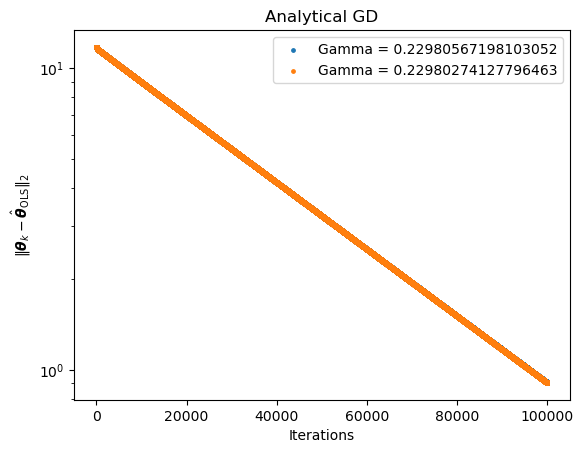

In [58]:
x, y = make_data()
gamma, num_iters, tol, upper_lim = set_parameters()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

gamma1 = largest_gamma 
gamma2 = fast_converge
gamma = [gamma1, gamma2]
num_iters = 100000

# Analytical gradient descent
for i in range(len(gamma)):
    theta_gdOLS = np.zeros(deg)
    theta_cfOLS = ols(X, y)
    errors = []
    for t in range(num_iters):
        err_OLS = np.linalg.norm(theta_gdOLS - theta_cfOLS)
        errors.append(err_OLS)
        if err_OLS >= tol:
            grad_OLS = analytic_grad_OLS(theta_gdOLS, X, y)
            theta_gdOLS = theta_gdOLS - gamma[i]*grad_OLS
        else:
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, iterations: {t}")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
            break
        if t == (num_iters-1):
            print(f"Gamma = {gamma[i]}: coefficients: {theta_gdOLS}, not converged, error={errors[-1]}")
            its = np.arange(0, t+1, 1)
            plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
        if np.linalg.norm(grad_OLS) >= upper_lim:
                print(f"Gamma=({gamma[i]}): coefficients: {theta_gdOLS}, DIVERGED, error={errors[-1]}")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(errors), label=f"Gamma = {gamma[i]}", s=6)
                break

plt.legend()
plt.title("Analytical GD")
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

Even with optimal learning rate the gradient descent does not get closer than an error of 0.9 to the closed form OLS solution. I DON'T UNDERSTAND WHY. 

Gamma=(0.98*2/Ridge_eigmax), lam=0.1: coefficients: [ 5.18618947e-03 -2.69120222e-01  1.95192460e-02 -1.22271512e-02
  6.61851010e-06  4.61950224e-02 -1.56724641e-02  5.88987956e-02], iterations: 291


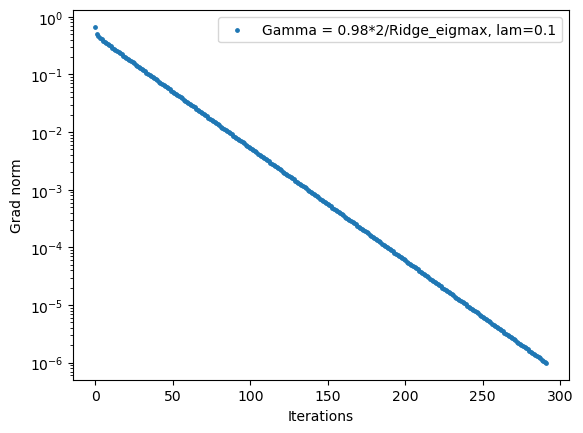

In [59]:
x, y = make_data()
gamma, num_iters, tol, upper_lim = set_parameters()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

lmbdas = [0.1]

for lam in lmbdas:
    eigmax, eigmin = eigenvalues(X, y, lam)
    fast_converge = 2 / (eigmax + eigmin)
    gamma = [fast_converge]
    for i in range(len(gamma)):
        theta_gdRidge = np.zeros(deg)
        theta_cfRidge = ridge(X, y, lam)
        grads = []
        for t in range(num_iters):
            grad_Ridge = analytic_grad_Ridge(theta_gdRidge, X, y, lam)
            grads.append(np.linalg.norm(grad_Ridge))
            if np.linalg.norm(grad_Ridge) >= tol:
                theta_gdRidge = theta_gdRidge - gamma[i]*grad_Ridge
            else:
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, iterations: {t}")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
                break
            if t == (num_iters-1):
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, not converged")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
            if np.linalg.norm(grad_Ridge) >= upper_lim:
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, DIVERGED")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
                break

    
plt.legend()
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Grad norm")
plt.show()

For larger values of lambda, the gradient descent converges more quickly. 

Gamma=(1.00*2/Ridge_eigmax), lam=2e-05: coefficients: [-0.06842165 -1.24332717  0.24552366  2.30413049 -0.40457942 -1.51139463
  0.16254825  0.27592582], not converged


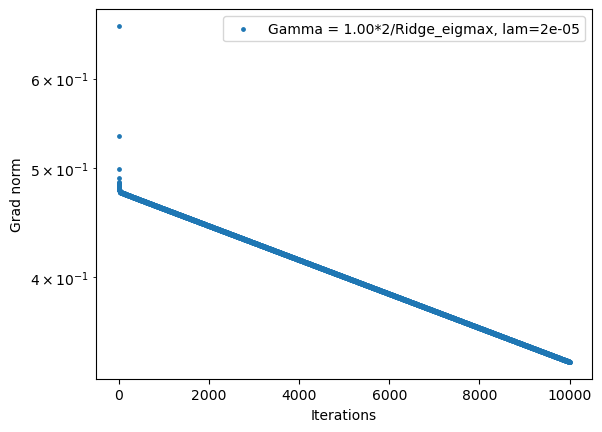

In [60]:
x, y = make_data()
gamma, num_iters, tol, upper_lim = set_parameters()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

num_iters = 10000
lmbdas = [2e-5]

for lam in lmbdas:
    eigmax, eigmin = eigenvalues(X, y, lam)
    fast_converge = 2 / (eigmax + eigmin)
    gamma = [fast_converge]
    for i in range(len(gamma)):
        theta_gdRidge = np.zeros(deg)
        theta_cfRidge = ridge(X, y, lam)
        grads = []
        for t in range(num_iters):
            grad_Ridge = analytic_grad_Ridge(theta_gdRidge, X, y, lam)
            grads.append(np.linalg.norm(grad_Ridge))
            if np.linalg.norm(grad_Ridge) >= tol:
                theta_gdRidge = theta_gdRidge - gamma[i]*grad_Ridge
            else:
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, iterations: {t}")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
                break
            if t == (num_iters-1):
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, not converged")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
            if np.linalg.norm(grad_Ridge) >= upper_lim:
                print(f"Gamma=({(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax), lam={lam}: coefficients: {theta_gdRidge}, DIVERGED")
                its = np.arange(0, t+1, 1)
                plt.scatter(its, np.array(grads), label=f"Gamma = {(gamma[i]*eigmax/2):.2f}*2/Ridge_eigmax, lam={lam}", s=6)
                break

    
plt.legend()
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Grad norm")
plt.show()

For the optimal degree and lambda found in part b).

### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

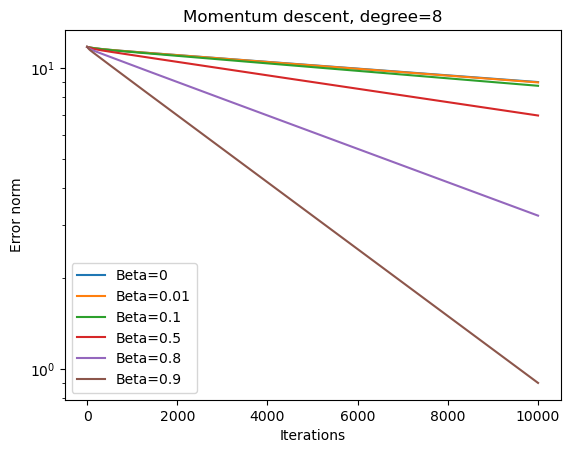

In [62]:
# Momentum

def momentum_descent(X, y, gamma, beta, lam=0.0, num_iters=10000, tol=1e-6):
    theta, v = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    theta_cf = ridge(X, y, lam)
    history = [np.linalg.norm(theta-theta_cf)]
    v = 0
    for t in range(num_iters):
        g = analytic_grad_Ridge(theta, X, y, lam)
        v = beta * v + gamma * g
        theta = theta - v
        history.append(np.linalg.norm(theta-theta_cf))
        if np.linalg.norm(theta-theta_cf) < tol:
            break
    return np.array(history), t + 1

x, y = make_data()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

eigmax, eigmin = eigenvalues(X, y, lam=0.0)
fast_converge = 2 / (eigmax + eigmin)
gamma = [fast_converge]

betas = [0, 0.01, 0.1, 0.5, 0.8, 0.9]
for beta in betas:
    precision, its = momentum_descent(X, y, gamma, beta)
    plt.plot(np.arange(0, its+1, 1), precision, label=f"Beta={beta}") 

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Error norm")
plt.title(f"Momentum descent, degree={8}")
plt.legend()
plt.show()

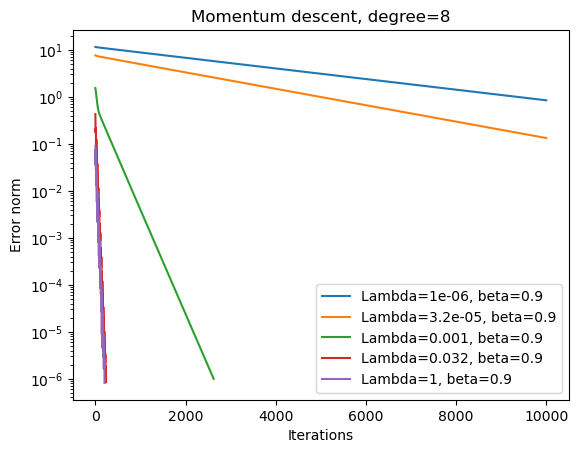

In [63]:
betas = [0.9]
lmbdas = np.logspace(-6, 0, 5)

for l in lmbdas:
    eigmax, eigmin = eigenvalues(X, y, l)
    fast_converge = 2 / (eigmax + eigmin)
    gamma = [fast_converge]

    for beta in betas:
        precision, its = momentum_descent(X, y, gamma, beta, lam=l)
        plt.plot(np.arange(0, its+1, 1), precision, label=f"Lambda={l:.2g}, beta={beta}") 

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Error norm")
plt.title(f"Momentum descent, degree={8}")
plt.legend()
plt.show()

In [64]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        v = beta*state.get("v", 0.0) + gamma*g
        state["v"] = v
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        r = state.get("r", 0.0) + g*g
        state["r"] = r
        return theta - gamma * g / np.sqrt(eps + state.get("r", 0.0)), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        r = rho*state.get("r", 0.0) + (1-rho)*g*g
        state["r"] = r
        return theta - gamma * g / np.sqrt(eps + state.get("r", 0.0)), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        m = beta1*state.get("m", 0.0) + (1-beta1)*g
        r = beta2*state.get("r", 0.0) + (1-beta2)*g*g
        state["m"] = m 
        state["r"] = r
        m_hat, r_hat = m / (1-beta1**t), r / (1-beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    upper_lim = 1e4
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
        if np.linalg.norm(g) > upper_lim:
            break
    return np.array(history), t

def gd_comparison(GD_RUNS, X, y, lam=0.0, num_iters=30000, tol=1e-8):
    """Error norm for the five optimisers."""
    theta_cf = ridge(X, y, lam)
    eigmax, eigmin = eigenvalues(X, y, lam)
    gamma_gd = 2 / (eigmax + eigmin)
    grad = lambda th: analytic_grad_Ridge(th, X, y, lam)
    out = {}
    for method, gamma, _, _ in GD_RUNS:
        g = gamma_gd if gamma is None else gamma
        path, _ = optimise(grad, np.zeros(X.shape[1]), method, g, num_iters=num_iters, tol=tol)
        out[method] = np.array([np.linalg.norm(th - theta_cf) for th in path])
    return out, eigmax, eigmin, gamma_gd

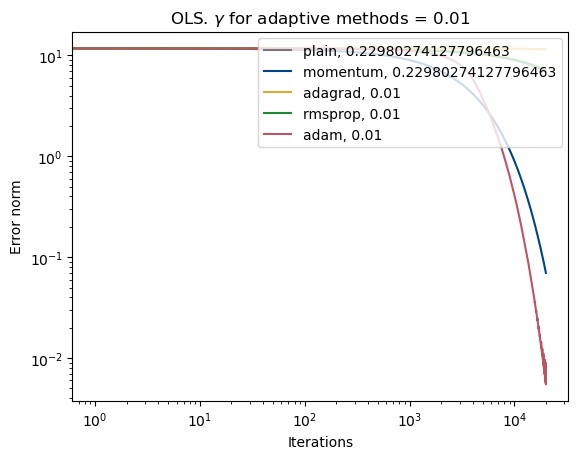

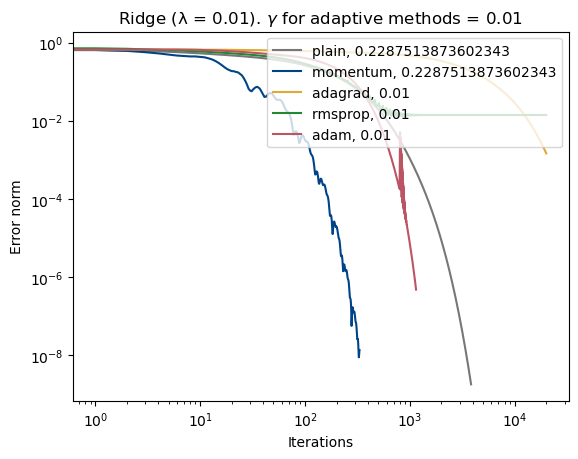

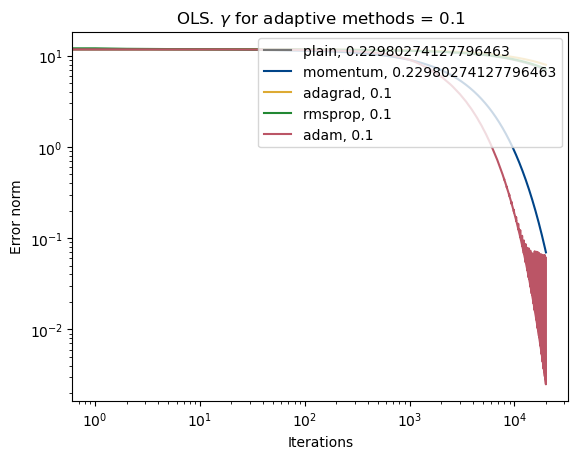

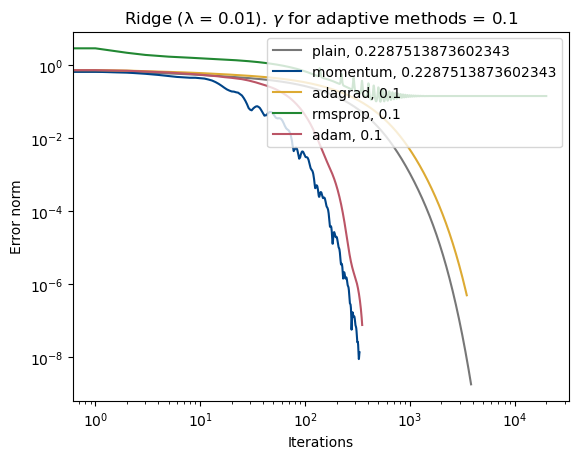

In [66]:
x, y = make_data()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

for gam in [0.01, 0.1]:
    GD_RUNS = (
    ('plain', None, '#777777', 'Plain GD'),
    ('momentum', None, '#004488', 'Momentum, $\\beta=0.9$'),
    ('adagrad', gam, '#DDAA33', 'AdaGrad'),
    ('rmsprop', gam, '#228833', 'RMSProp'),
    ('adam', gam, '#BB5566', 'Adam')
)
    for lam in [0, 0.01]:
        error, eigmax, eigmin, gamma_gd = gd_comparison(GD_RUNS, X, y, lam=lam, num_iters=20000)
        for method, gamma, color, _ in GD_RUNS:            
            g = gamma_gd if gamma is None else gamma
            e = error[method]
            its = np.arange(0, len(e), 1)
            plt.plot(its, e, color=color, label=f"{method}, {g}")
        plt.legend(loc="upper right")
        plt.xscale("log")
        plt.yscale("log")
        plt.ylabel("Error norm")
        plt.xlabel("Iterations")
        plt.title(f"OLS. $\\gamma$ for adaptive methods = {g:.2g}" if lam == 0 else f"Ridge (λ = {lam}). $\\gamma$ for adaptive methods = {g:.2g}")
        plt.show()

LAG PLOT 
som viser 
hvor mange iterations som trengtes for å nå tolerance for de forskjellige metodene for de learning rates som når tolerance. 
!!!!!!!!!

### Part g): Writing our own code for Lasso regression

The $\ell_1$ penalty $\lambda\|\boldsymbol{\theta}\|_1$ is not differentiable
at $\theta_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\theta|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

In [67]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
#print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
#print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))


def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

def cost_lasso(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(jnp.abs(theta))
    
x, y = make_data()
deg = 8
X, y, _, _ = split_stand(x, y, deg)
theta = np.zeros(X.shape[1])

grad_OLS = jax.grad(cost_ols)(theta, X, y)
grad_Ridge = jax.grad(cost_ridge)(theta, X, y, 0.1)
grad_Lasso = jax.grad(cost_lasso)(theta, X, y, 0.1)

print(grad_OLS)
print(grad_Ridge)
print(grad_Lasso)

[ 0.02688707  0.42735417  0.02028554  0.33578696  0.00312798  0.28815641
 -0.01562438  0.25749163]
[ 0.02688707  0.42735417  0.02028554  0.33578696  0.00312798  0.28815641
 -0.01562438  0.25749163]
[0.12688707 0.52735417 0.12028554 0.43578696 0.10312798 0.38815641
 0.08437562 0.35749163]


In [68]:
# Lasso

def momentum_descent(X, y, gamma, beta, lam=0.0, num_iters=1000, tol=1e-4):
    theta, v = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    g = jax.grad(cost_lasso)(theta, X, y, lam)
    history = [np.linalg.norm(g)]
    v = 0
    for t in range(num_iters):
        g = jax.grad(cost_lasso)(theta, X, y, lam)
        v = beta * v + gamma * g
        theta = theta - v
        history.append(np.linalg.norm(g))
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t + 1

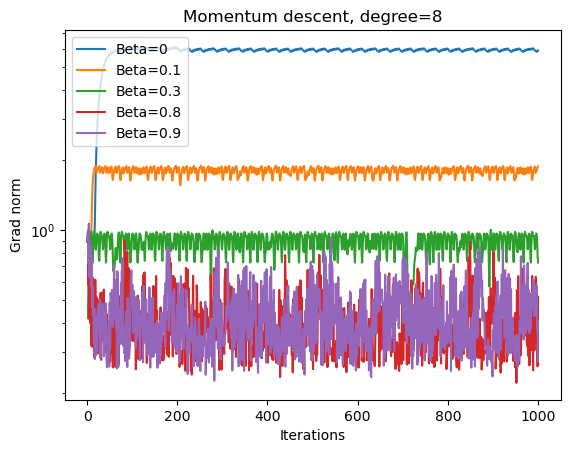

In [69]:
x, y = make_data()
deg = 8
X, y, _, _ = split_stand(x, y, deg)

lam = 0.1

eigmax, eigmin = eigenvalues(X, y, lam)
fast_converge = 2 / (eigmax + eigmin)
gamma = fast_converge

betas = [0, 0.1, 0.3, 0.8, 0.9]
for beta in betas:
    precision, its = momentum_descent(X, y, gamma, beta, lam)
    plt.plot(np.arange(0, its+1, 1), precision, label=f"Beta={beta}") 

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Grad norm")
plt.title(f"Momentum descent, degree={8}")
plt.legend()
plt.show()

The momentum gradient descent approach using jax for the Lasso gradient, does not converge for any of the betas tried. Should try different gradient method?

### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

In [509]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = jax.grad(cost_ridge)(theta, X[batch, :], y[batch], lam)   # the gradient of the cost on this minibatch
            gamma_t =  gamma if schedule is None else step_length(t, *schedule) # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

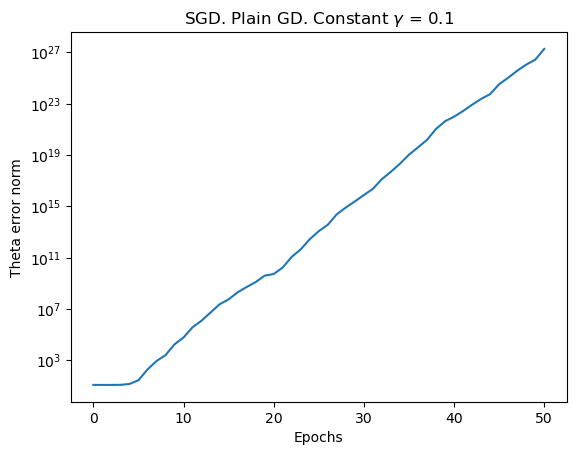

In [521]:
x, y = make_data()
deg = 8
X, y, _, _ = split_stand(x, y, deg)
thetas = sgd(X, y)
theta_cf = ols(X, y)
d = np.linalg.norm(thetas - theta_cf, axis=1)

plt.plot(range(len(d)), d)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Theta error norm")
plt.title(f"SGD. Plain GD. Constant $\\gamma$ = 0.1")
plt.show()

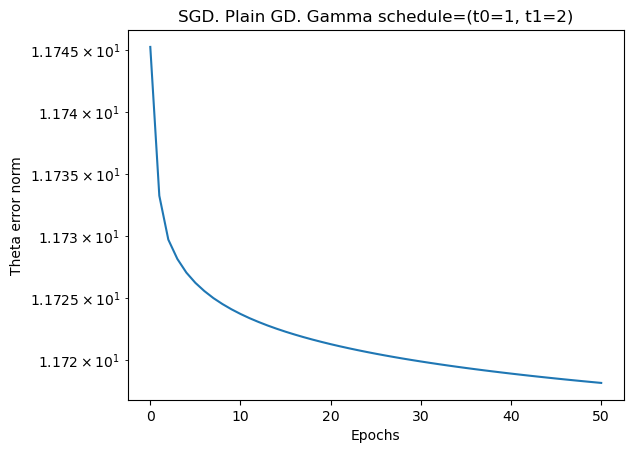

In [524]:
t0, t1 = 1.0, 2.0
thetas = sgd(X, y, schedule=(t0, t1))
theta_cf = ols(X, y)
d = np.linalg.norm(thetas - theta_cf, axis=1)

plt.plot(range(len(d)), d)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Theta error norm")
plt.title("SGD. Plain GD. Gamma schedule=(t0=1, t1=2)")
plt.show()

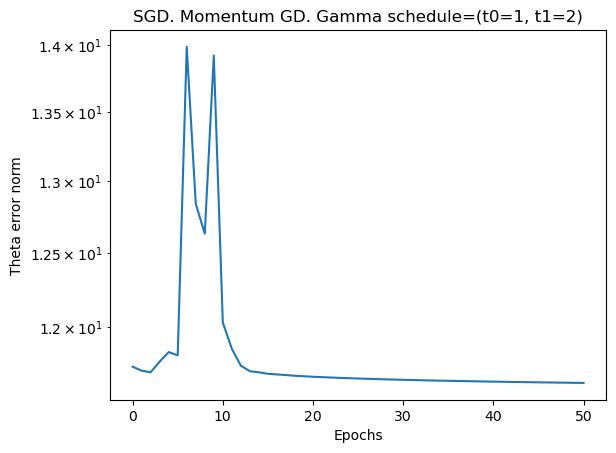

In [526]:
t0, t1 = 1.0, 10.0
thetas = sgd(X, y, method="momentum", schedule=(t0, t1))
theta_cf = ols(X, y)
d = np.linalg.norm(thetas - theta_cf, axis=1)

plt.plot(range(len(d)), d)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Theta error norm")
plt.title("SGD. Momentum GD. Gamma schedule=(t0=1, t1=2)")
plt.show()

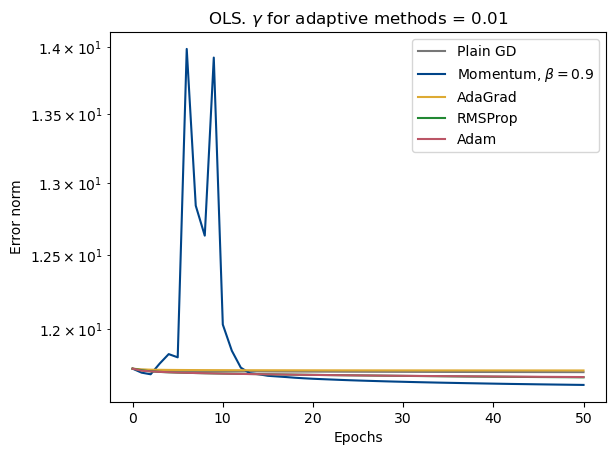

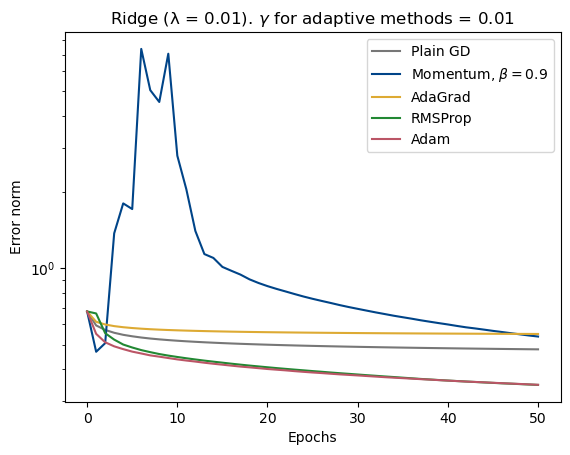

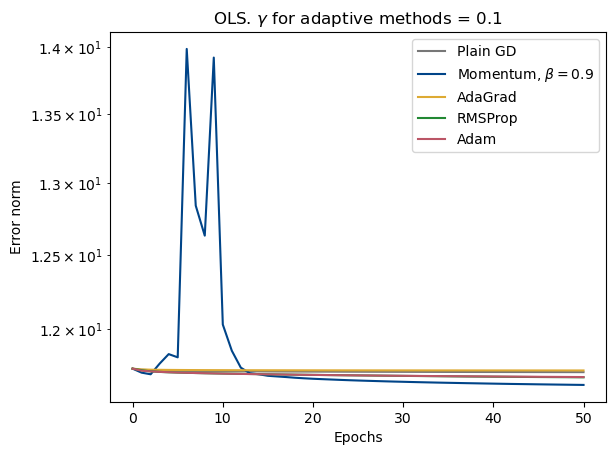

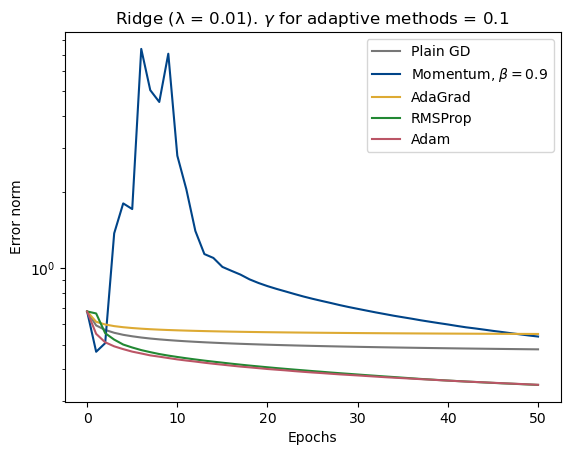

In [528]:
for gam in [0.01, 0.1]:
    GD_RUNS = (
    ('plain', None, '#777777', 'Plain GD'),
    ('momentum', None, '#004488', 'Momentum, $\\beta=0.9$'),
    ('adagrad', gam, '#DDAA33', 'AdaGrad'),
    ('rmsprop', gam, '#228833', 'RMSProp'),
    ('adam', gam, '#BB5566', 'Adam')
)
    for lam in [0, 0.01]:
        for m, gamma, color, label in GD_RUNS:            
            g = gamma_gd if gamma is None else gamma
            thetas = sgd(X, y, method=m, gamma=g, schedule=(t0, t1), lam=lam)
            d = np.linalg.norm(thetas - ridge(X, y, lam), axis=1)
            eps = np.arange(0, len(d), 1)
            plt.plot(eps, d, color=color, label=label)
        plt.legend(loc="upper right")
        plt.yscale("log")
        plt.ylabel("Error norm")
        plt.xlabel("Epochs")
        plt.title(f"OLS. $\\gamma$ for adaptive methods = {g:.2g}" if lam == 0 else f"Ridge (λ = {lam}). $\\gamma$ for adaptive methods = {g:.2g}")
        plt.show()

In [529]:
#PRØV FOR DEGREE 2 og 5 

### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

In [11]:
# Your code for part i) here

## Background literature

- The lecture notes of the course, in particular Chapter 2 (Sections 2.9–2.12
  on training and test error, the bias-variance tradeoff, the bootstrap and
  cross-validation), Chapter 3 (linear regression, Ridge, Lasso, scaling) and
  Chapter 4 (gradient descent methods and automatic differentiation).
- For a discussion and derivation of the variances and mean squared errors
  using linear regression, see the
  [Lecture notes on ridge regression by Wessel N. van Wieringen](https://arxiv.org/abs/1509.09169).
- The textbook of
  [Trevor Hastie, Robert Tibshirani, Jerome H. Friedman, The Elements of Statistical Learning, Springer](https://www.springer.com/gp/book/9780387848570);
  chapters 3 and 7 are the most relevant ones for the analysis here.
- On automatic differentiation:
  [Baydin et al., Automatic differentiation in machine learning: a survey, JMLR 18 (2018)](https://jmlr.org/papers/v18/17-468.html),
  and the [JAX documentation](https://jax.readthedocs.io).

## Introduction to numerical projects

Here follows a brief recipe and recommendation on how to answer the various
questions when preparing your answers.

- Give a short description of the nature of the problem and the eventual
  numerical methods you have used.
- Describe the algorithm you have used and/or developed. Here you may find it
  convenient to use pseudocoding. In many cases you can describe the algorithm
  in the program itself.
- Include the source code of your program. Comment your program properly. You
  should have the code at your GitHub/GitLab link. You can also place the code
  in an appendix of your report.
- If possible, try to find analytic solutions, or known limits in order to test
  your program when developing the code. In this project the closed-form OLS
  and Ridge solutions are exactly such tests for your gradient descent codes.
- Include your results either in figure form or in a table. Remember to label
  your results. All tables and figures should have relevant captions and labels
  on the axes.
- Try to evaluate the reliability and numerical stability/precision of your
  results. If possible, include a qualitative and/or quantitative discussion of
  the numerical stability, eventual loss of precision etc.
- Try to give an interpretation of your results in your answers to the
  problems.
- Critique: if possible include your comments and reflections about the
  exercise, whether you felt you learnt something, ideas for improvements and
  other thoughts you've made when solving the exercise. We wish to keep this
  course at the interactive level and your comments can help us improve it.
- Try to establish a practice where you log your work at the computer lab. You
  may find such a logbook very handy at later stages in your work, especially
  when you don't properly remember what a previous test version of your program
  did. Here you could also record the time spent on solving the exercise,
  various algorithms you may have tested or other topics which you feel worthy
  of mentioning.

## Format for electronic delivery of report and programs

The preferred format for the report is a PDF file. You can also use DOC or
postscript formats or an IPython notebook file. As programming language we
prefer that you choose between C/C++, Fortran2008, Julia or Python. The
following prescription should be followed when preparing the report:

- Use Canvas to hand in your projects, log in at
  <https://www.uio.no/english/services/it/education/canvas/> with your normal
  UiO username and password.
- Upload **only** the report file or the link to your GitHub/GitLab or similar
  type of repository! For the source code file(s) you have developed please
  provide us with your link to your GitHub/GitLab or similar domain. The report
  file should include all of your discussions and a list of the codes you have
  developed. Do not include library files which are available at the course
  homepage, unless you have made specific changes to them.
- In your GitHub/GitLab or similar repository, please include a folder which
  contains selected results. These can be in the form of output from your code
  for a selected set of runs and input parameters.

Finally, we encourage you to collaborate. Optimal working groups consist of 2–3
students. You can then hand in a common report.

## Software and needed installations

If you have Python installed (we recommend Python 3) and you feel pretty
familiar with installing different packages, we recommend that you install the
following Python packages via `pip` as

    pip install numpy scipy matplotlib ipython jupyter scikit-learn pandas jax jaxlib

(`autograd` is a lighter alternative to JAX for the automatic differentiation in
parts e)–g)). For Python 3, replace `pip` with `pip3` where needed.

For OSX users we recommend also, after having installed Xcode, to install
`brew`. Brew allows for a seamless installation of additional software via for
example `brew install python3`. For Linux users, with its variety of
distributions like for example the widely popular Ubuntu distribution, you can
use `pip` as well and simply install Python as `sudo apt-get install python3`
etc.

If you don't want to install various Python packages with their dependencies
separately, we recommend [Anaconda](https://docs.anaconda.com/), an open source
distribution of the Python and R programming languages for large-scale data
processing, predictive analytics, and scientific computing, that aims to
simplify package management and deployment. Package versions are managed by the
package management system `conda`.

Popular software packages written in Python for ML are
[Scikit-learn](http://scikit-learn.org/stable/), [JAX](https://jax.readthedocs.io),
[TensorFlow](https://www.tensorflow.org/), [PyTorch](http://pytorch.org/) and
[Keras](https://keras.io/). These are all freely available at their respective
GitHub sites. They encompass communities of developers in the thousands or more,
and the number of code developers and contributors keeps increasing.